## Mount Drive and set paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT     = Path('/content/drive/MyDrive/derm9')
DATA        = PROJECT / 'data'
FIGURES     = PROJECT / 'figures'
CHECKPOINTS = PROJECT / 'checkpoints'

# Safe to re-run; existing folders aren't touched.
for folder in [DATA, FIGURES, CHECKPOINTS]:
    folder.mkdir(parents=True, exist_ok=True)

print('Project root :', PROJECT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root : /content/drive/MyDrive/derm9


## Imports

In [ ]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision import models
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

SEED = 99
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## Reload splits and class mapping


In [ ]:
# Combined splits CSV — one row per image, with a 'split' column.
splits_df = pd.read_csv(DATA / 'derm9_splits.csv')

# Filter back into three DataFrames.
train_df = splits_df[splits_df['split'] == 'train'].reset_index(drop=True)
val_df   = splits_df[splits_df['split'] == 'val'].reset_index(drop=True)
test_df  = splits_df[splits_df['split'] == 'test'].reset_index(drop=True)

# Class-to-index mapping JSON.
with open(DATA / 'derm9_class_mapping.json') as f:
    class_to_idx = json.load(f)
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

print(f'Train: {len(train_df):,} images')
print(f'Val  : {len(val_df):,} images')
print(f'Test : {len(test_df):,} images')
print(f'\nClass mapping ({len(class_to_idx)} classes):')
for cls, i in class_to_idx.items():
    print(f'  {i}: {cls}')

Train: 1,227 images
Val  : 409 images
Test : 409 images

Class mapping (8 classes):
  0: actinic keratosis
  1: basal cell carcinoma
  2: dermatofibroma
  3: melanoma
  4: nevus
  5: pigmented benign keratosis
  6: squamous cell carcinoma
  7: vascular lesion


## Define transforms

In [ ]:
# No augmentation: resize, crop, to tensor in [0, 1].
basic_tfm = v2.Compose([
    v2.Resize(256, antialias=True),
    v2.CenterCrop(224),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
])

# With augmentation: same as basic plus random flips, rotation, color jitter.
augmented_tfm = v2.Compose([
    v2.Resize(256, antialias=True),
    v2.CenterCrop(224),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(0.1, 0.1, 0.1, 0.02),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
])

print('Transforms ready: basic_tfm, augmented_tfm')

Transforms ready: basic_tfm, augmented_tfm


## Recreate Dataset class and DataLoaders

In [ ]:
class SkinLesionDataset(Dataset):
    """One row of the DataFrame becomes one (image_tensor, label) sample."""

    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        label = self.class_to_idx[row['class_orig']]
        return img, label


BATCH_SIZE = 32

train_ds = SkinLesionDataset(train_df, class_to_idx, transform=augmented_tfm)
val_ds   = SkinLesionDataset(val_df,   class_to_idx, transform=basic_tfm)
test_ds  = SkinLesionDataset(test_df,  class_to_idx, transform=basic_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_ds):,} samples, {len(train_loader):,} batches')
print(f'Val  : {len(val_ds):,} samples, {len(val_loader):,} batches')
print(f'Test : {len(test_ds):,} samples, {len(test_loader):,} batches')

Train: 1,227 samples, 39 batches
Val  : 409 samples, 13 batches
Test : 409 samples, 13 batches


## Training and evaluation functions
Define the helper functions that every model will use to train and evaluate.


In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    """One pass over the training set. Returns avg loss and accuracy."""
    model.train()  # enable dropout and any train-specific behavior
    total_loss = 0.0
    correct = 0
    seen = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Standard PyTorch training step.
        optimizer.zero_grad()             # clear old gradients
        logits = model(images)            # forward pass
        loss = loss_fn(logits, labels)    # compute loss
        loss.backward()                   # compute gradients
        optimizer.step()                  # update weights

        # Accumulate stats. .item() pulls a Python float off the GPU.
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        seen       += images.size(0)

    return total_loss / seen, correct / seen


@torch.no_grad()  # disable gradient tracking; saves memory and time
def evaluate(model, loader, loss_fn, device):
    """Run the model on a loader. Returns avg loss and accuracy."""
    model.eval()  # disable dropout, freeze batchnorm running stats
    total_loss = 0.0
    correct = 0
    seen = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = loss_fn(logits, labels)

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        seen       += images.size(0)

    return total_loss / seen, correct / seen


def fit(model, train_loader, val_loader, optimizer, loss_fn, device,
        epochs, patience=None):
    """Train for up to `epochs`, optionally stopping early on val loss."""
    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}

    best_val_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                           loss_fn, device)
        vl_loss, vl_acc = evaluate(model, val_loader, loss_fn, device)
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f'Epoch {epoch:3d} | '
              f'train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
              f'val loss {vl_loss:.4f} acc {vl_acc:.3f} | '
              f'{elapsed:.1f}s')

        # Track the best val loss so we can restore those weights at the end.
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # EarlyStopping — only fires if patience was set.
        if patience is not None and epochs_without_improvement >= patience:
            print(f'\nNo improvement for {patience} epochs, stopping early.')
            break

    # Restore best weights (the ones from the lowest-val-loss epoch).
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## Define the baseline CNN
A small CNN trained from scratch, with no augmentation and no regularization. Establishes a performance floor for the next two models to beat.



In [ ]:
class BaselineCNN(nn.Module):

    def __init__(self, num_classes: int = 8):
        super().__init__()


        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),

            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),
        )

        # Classifier head: ReLU + 256 -> 128 -> num_classes.
        # No dropout — this is the baseline.
        self.head = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x


baseline = BaselineCNN(num_classes=len(class_to_idx)).to(DEVICE)

n_params = sum(p.numel() for p in baseline.parameters())
print(f'Baseline CNN (4 blocks): {n_params:,} parameters')
print(baseline)

Baseline CNN (4 blocks): 13,267,656 parameters
BaselineCNN(
  (backbone): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=50176, out_features=256, bias=True)
  )
  (head): Sequential(
    (0): ReLU(inplace=True)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_feature

##  Train the baseline

In [ ]:
# Use the basic_tfm train loader (no augmentation) for the baseline.
baseline_train_ds = SkinLesionDataset(train_df, class_to_idx, transform=basic_tfm)
baseline_train_loader = DataLoader(
    baseline_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
)

# Adam optimizer, default learning rate. CrossEntropyLoss for 8-class output.
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Train for the full 30 epochs (patience=None disables EarlyStopping).
print('--- Baseline CNN (4 blocks) ---\n')
baseline_history = fit(
    model=baseline,
    train_loader=baseline_train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=DEVICE,
    epochs=30,
    patience=None,
)

--- Baseline CNN (4 blocks) ---

Epoch   1 | train loss 1.9415 acc 0.201 | val loss 1.9295 acc 0.269 | 19.5s
Epoch   2 | train loss 1.8207 acc 0.310 | val loss 1.7948 acc 0.364 | 18.8s
Epoch   3 | train loss 1.6234 acc 0.368 | val loss 1.5911 acc 0.379 | 18.8s
Epoch   4 | train loss 1.5560 acc 0.417 | val loss 1.7570 acc 0.345 | 20.0s
Epoch   5 | train loss 1.5050 acc 0.428 | val loss 1.4395 acc 0.509 | 18.4s
Epoch   6 | train loss 1.4442 acc 0.451 | val loss 1.3987 acc 0.523 | 18.9s
Epoch   7 | train loss 1.3543 acc 0.500 | val loss 1.3863 acc 0.523 | 18.9s
Epoch   8 | train loss 1.3278 acc 0.526 | val loss 1.4239 acc 0.513 | 18.5s
Epoch   9 | train loss 1.3223 acc 0.513 | val loss 1.5112 acc 0.482 | 19.3s
Epoch  10 | train loss 1.2590 acc 0.541 | val loss 1.4832 acc 0.567 | 19.1s
Epoch  11 | train loss 1.2318 acc 0.548 | val loss 1.4585 acc 0.509 | 19.3s
Epoch  12 | train loss 1.1478 acc 0.577 | val loss 1.4054 acc 0.555 | 18.4s
Epoch  13 | train loss 1.2008 acc 0.563 | val loss 1.43

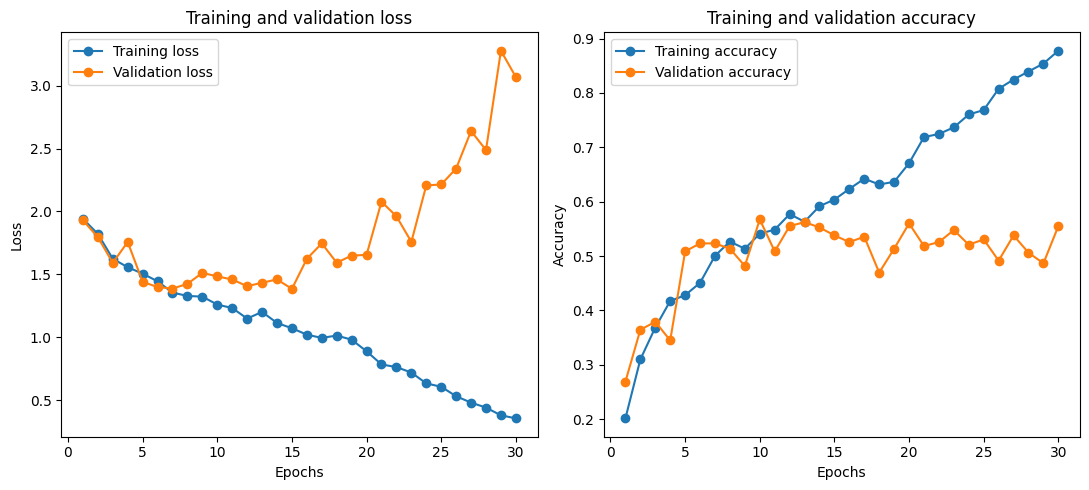

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(baseline_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Loss
ax1.plot(epochs, baseline_history['train_loss'], 'o-', label='Training loss')
ax1.plot(epochs, baseline_history['val_loss'],   'o-', label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training and validation loss')
ax1.legend()

# Accuracy
ax2.plot(epochs, baseline_history['train_acc'], 'o-', label='Training accuracy')
ax2.plot(epochs, baseline_history['val_acc'],   'o-', label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and validation accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'baseline_curves.png', dpi=100, bbox_inches='tight')
plt.show()

The training loss keeps falling while the validation loss climbs after a few epochs. The model is memorizing the training set instead of learning patterns that generalize.

##  Per-class metrics on the baseline

Compute the confusion matrix and per-class precision/recall/F1 for the baseline on the validation set.

Aggregate accuracy can hide bad behavior on rare classes. A model that gets the majority class right and ignores the rest can still report decent accuracy. Per-class metrics surface those imbalances.



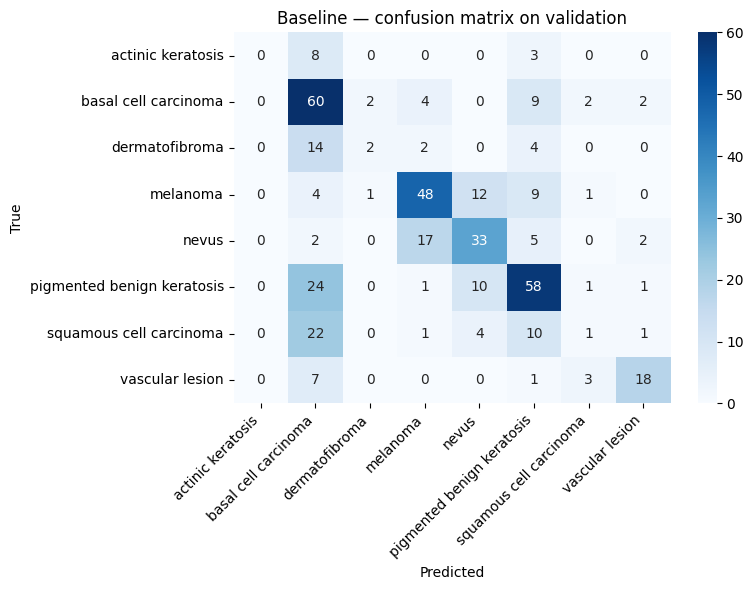

                            precision    recall  f1-score   support

         actinic keratosis      0.000     0.000     0.000        11
      basal cell carcinoma      0.426     0.759     0.545        79
            dermatofibroma      0.400     0.091     0.148        22
                  melanoma      0.658     0.640     0.649        75
                     nevus      0.559     0.559     0.559        59
pigmented benign keratosis      0.586     0.611     0.598        95
   squamous cell carcinoma      0.125     0.026     0.043        39
           vascular lesion      0.750     0.621     0.679        29

                  accuracy                          0.538       409
                 macro avg      0.438     0.413     0.403       409
              weighted avg      0.506     0.538     0.504       409



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# class_names; list of class names in index order, used to label the heatmap.
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]


# Helper: run the model on a loader and return arrays of true and predicted labels.
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_true, all_pred = [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        preds  = logits.argmax(1).cpu().numpy()
        all_true.append(labels.numpy())
        all_pred.append(preds)
    return np.concatenate(all_true), np.concatenate(all_pred)


# Predictions on the val set with the baseline.
y_true, y_pred = collect_predictions(baseline, val_loader, DEVICE)

# Confusion matrix.
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Baseline — confusion matrix on validation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / 'baseline_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

# Per-class precision, recall, F1.
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

The baseline reaches 0.562 accuracy but only 0.394 macro F1. The gap is the dataset imbalance showing up: the model learned the four largest classes and ignored three of the four smallest.

## Augmented + regularized model

Train a 4-block CNN with augmentation, dropout, and EarlyStopping. See how much the regularization closes the gap the baseline opened.



In [ ]:
class RegularizedCNN(nn.Module):
    """Same backbone as the baseline, plus dropout in the head."""

    def __init__(self, num_classes: int = 8, dropout: float = 0.5):
        super().__init__()

        # Identical backbone to BaselineCNN.
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),

            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),
        )

        # Same head structure plus dropout between each pair of Linear layers.
        self.head = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x


regularized = RegularizedCNN(num_classes=len(class_to_idx), dropout=0.5).to(DEVICE)

n_params = sum(p.numel() for p in regularized.parameters())
print(f'Regularized CNN: {n_params:,} parameters')

Regularized CNN: 13,267,656 parameters


In [ ]:
# train_loader uses augmented_tfm
optimizer = optim.Adam(regularized.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print('--- Regularized CNN ---\n')
regularized_history = fit(
    model=regularized,
    train_loader=train_loader,    # augmented
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=DEVICE,
    epochs=50,
    patience=5,
)

--- Regularized CNN ---

Epoch   1 | train loss 1.9806 acc 0.196 | val loss 1.8850 acc 0.232 | 22.9s
Epoch   2 | train loss 1.9121 acc 0.237 | val loss 1.8527 acc 0.269 | 22.7s
Epoch   3 | train loss 1.9037 acc 0.263 | val loss 1.7728 acc 0.325 | 24.3s
Epoch   4 | train loss 1.7607 acc 0.309 | val loss 1.6719 acc 0.364 | 23.8s
Epoch   5 | train loss 1.7078 acc 0.321 | val loss 1.7932 acc 0.311 | 23.0s
Epoch   6 | train loss 1.6348 acc 0.359 | val loss 1.6540 acc 0.408 | 22.8s
Epoch   7 | train loss 1.6091 acc 0.375 | val loss 1.5503 acc 0.386 | 22.9s
Epoch   8 | train loss 1.6223 acc 0.364 | val loss 1.7898 acc 0.286 | 22.9s
Epoch   9 | train loss 1.6277 acc 0.376 | val loss 1.6048 acc 0.364 | 23.6s
Epoch  10 | train loss 1.5845 acc 0.390 | val loss 1.5199 acc 0.452 | 23.3s
Epoch  11 | train loss 1.5786 acc 0.398 | val loss 1.6772 acc 0.367 | 23.2s
Epoch  12 | train loss 1.5770 acc 0.398 | val loss 1.5131 acc 0.452 | 23.1s
Epoch  13 | train loss 1.5100 acc 0.424 | val loss 1.4376 acc 0

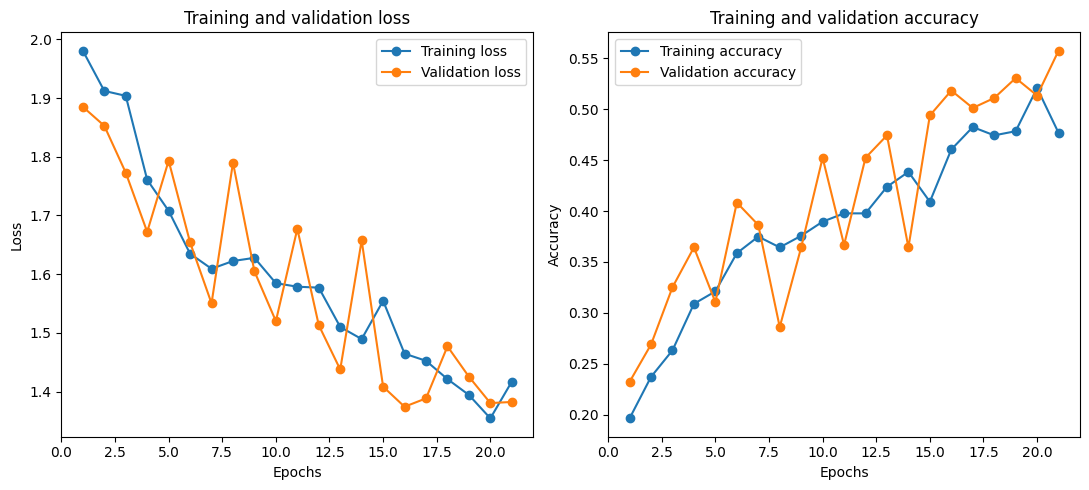

In [ ]:
epochs = range(1, len(regularized_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Loss
ax1.plot(epochs, regularized_history['train_loss'], 'o-', label='Training loss')
ax1.plot(epochs, regularized_history['val_loss'],   'o-', label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training and validation loss')
ax1.legend()

# Accuracy
ax2.plot(epochs, regularized_history['train_acc'], 'o-', label='Training accuracy')
ax2.plot(epochs, regularized_history['val_acc'],   'o-', label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and validation accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'regularized_curves.png', dpi=100, bbox_inches='tight')
plt.show()

The training and validation curves now track each other closely. Augmentation, dropout, and early stopping kept the overfitting in check.

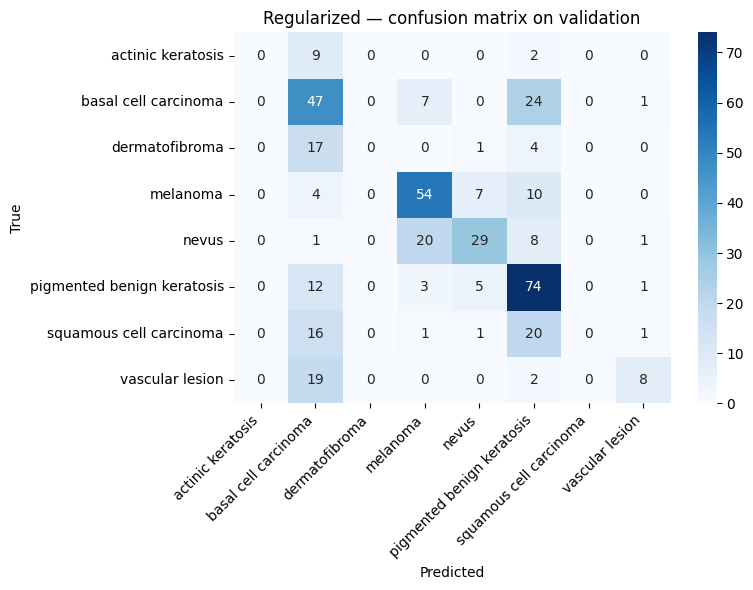

In [ ]:
# Same helper from before, now applied to the regularized model.
y_true, y_pred = collect_predictions(regularized, val_loader, DEVICE)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Regularized — confusion matrix on validation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / 'regularized_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

                            precision    recall  f1-score   support

         actinic keratosis      0.000     0.000     0.000        11
      basal cell carcinoma      0.376     0.595     0.461        79
            dermatofibroma      0.000     0.000     0.000        22
                  melanoma      0.635     0.720     0.675        75
                     nevus      0.674     0.492     0.569        59
pigmented benign keratosis      0.514     0.779     0.619        95
   squamous cell carcinoma      0.000     0.000     0.000        39
           vascular lesion      0.667     0.276     0.390        29

                  accuracy                          0.518       409
                 macro avg      0.358     0.358     0.339       409
              weighted avg      0.453     0.518     0.466       409



## Build the transfer learning model

Use ConvNeXt-Tiny pretrained on ImageNet as a frozen feature extractor, with a fresh classifier head trained on our data.



In [ ]:
# Build new transforms with ImageNet normalization.
train_tfm_pretrained = v2.Compose([
    v2.Resize(256, antialias=True),
    v2.CenterCrop(224),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(0.1, 0.1, 0.1, 0.02),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfm_pretrained = v2.Compose([
    v2.Resize(256, antialias=True),
    v2.CenterCrop(224),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# New Datasets and DataLoaders with these transforms.
transfer_train_ds = SkinLesionDataset(train_df, class_to_idx, transform=train_tfm_pretrained)
transfer_val_ds   = SkinLesionDataset(val_df,   class_to_idx, transform=eval_tfm_pretrained)
transfer_test_ds  = SkinLesionDataset(test_df,  class_to_idx, transform=eval_tfm_pretrained)

transfer_train_loader = DataLoader(transfer_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
transfer_val_loader   = DataLoader(transfer_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
transfer_test_loader  = DataLoader(transfer_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('Transfer-learning loaders ready.')

Transfer-learning loaders ready.


In [ ]:
# Load pretrained ConvNeXt-Tiny, freeze the backbone, replace the classifier.
backbone = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

# Freeze all parameters — they won't update during training.
for param in backbone.parameters():
    param.requires_grad = False

# Replace the classifier head. ConvNeXt-Tiny outputs 768-dim features.
# The new head has its own dropout for regularization.

backbone.classifier = nn.Sequential(
    nn.Flatten(),                         # (32, 768, 1, 1) -> (32, 768)
    nn.LayerNorm(768, eps=1e-6),          # now sees 768 as the last axis
    nn.Dropout(p=0.4),
    nn.Linear(768, 256),
    nn.GELU(),
    nn.Dropout(p=0.4),
    nn.Linear(256, len(class_to_idx)),
)

transfer_model = backbone.to(DEVICE)

n_total     = sum(p.numel() for p in transfer_model.parameters())
n_trainable = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
print(f'Total parameters    : {n_total:,}')
print(f'Trainable parameters: {n_trainable:,}  (only the new head)')
print(f'Frozen parameters   : {n_total - n_trainable:,}  (the pretrained backbone)')

Total parameters    : 28,019,048
Trainable parameters: 200,456  (only the new head)
Frozen parameters   : 27,818,592  (the pretrained backbone)


## Train the transfer model


In [ ]:
# Pass only the trainable head parameters to the optimizer.
trainable_params = [p for p in transfer_model.parameters() if p.requires_grad]

optimizer = optim.Adam(trainable_params, lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print('--- Transfer Learning (ConvNeXt-Tiny, frozen backbone) ---\n')
transfer_history = fit(
    model=transfer_model,
    train_loader=transfer_train_loader,
    val_loader=transfer_val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=DEVICE,
    epochs=35,
    patience=5,
)

--- Transfer Learning (ConvNeXt-Tiny, frozen backbone) ---

Epoch   1 | train loss 1.6463 acc 0.372 | val loss 1.3253 acc 0.523 | 28.1s
Epoch   2 | train loss 1.2927 acc 0.522 | val loss 1.2048 acc 0.533 | 22.9s
Epoch   3 | train loss 1.1838 acc 0.557 | val loss 1.0488 acc 0.621 | 23.1s
Epoch   4 | train loss 1.1132 acc 0.574 | val loss 1.0307 acc 0.641 | 21.7s
Epoch   5 | train loss 1.0292 acc 0.622 | val loss 0.9630 acc 0.658 | 21.7s
Epoch   6 | train loss 0.9983 acc 0.620 | val loss 0.9669 acc 0.663 | 22.2s
Epoch   7 | train loss 0.9880 acc 0.639 | val loss 0.9718 acc 0.660 | 22.3s
Epoch   8 | train loss 0.9545 acc 0.665 | val loss 0.9449 acc 0.663 | 22.4s
Epoch   9 | train loss 0.9355 acc 0.659 | val loss 0.9062 acc 0.667 | 22.0s
Epoch  10 | train loss 0.8786 acc 0.676 | val loss 0.9185 acc 0.677 | 22.3s
Epoch  11 | train loss 0.8996 acc 0.664 | val loss 0.9043 acc 0.667 | 22.0s
Epoch  12 | train loss 0.8788 acc 0.676 | val loss 0.8723 acc 0.675 | 21.9s
Epoch  13 | train loss 0.843

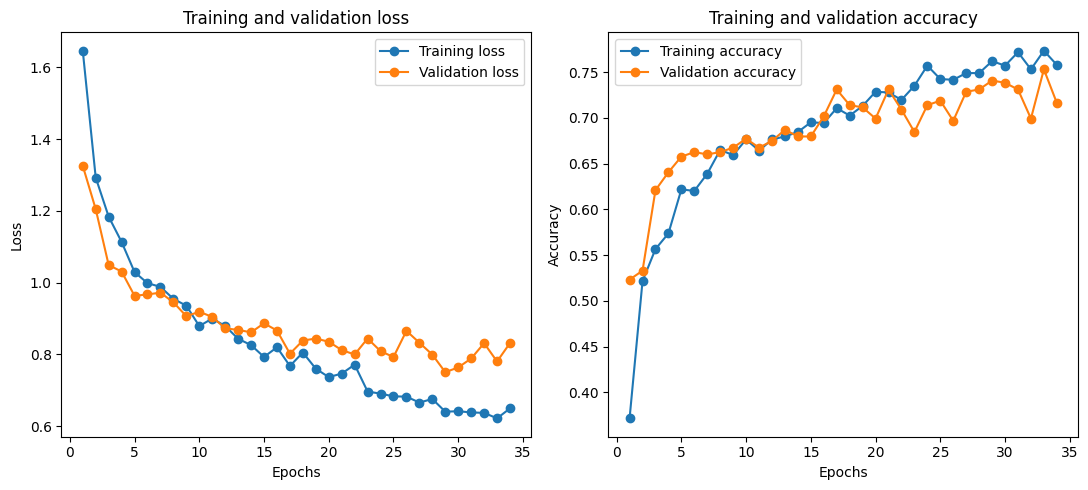

In [ ]:
epochs = range(1, len(transfer_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Loss
ax1.plot(epochs, transfer_history['train_loss'], 'o-', label='Training loss')
ax1.plot(epochs, transfer_history['val_loss'],   'o-', label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training and validation loss')
ax1.legend()

# Accuracy
ax2.plot(epochs, transfer_history['train_acc'], 'o-', label='Training accuracy')
ax2.plot(epochs, transfer_history['val_acc'],   'o-', label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and validation accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'transfer_curves.png', dpi=100, bbox_inches='tight')
plt.show()

Train and validation curves track each other closely throughout; much less overfitting than the from-scratch models.

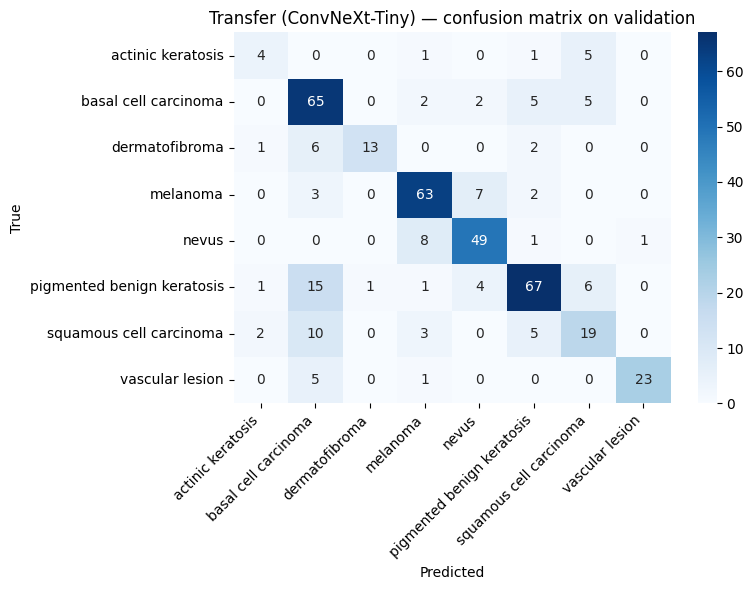

                            precision    recall  f1-score   support

         actinic keratosis      0.500     0.364     0.421        11
      basal cell carcinoma      0.625     0.823     0.710        79
            dermatofibroma      0.929     0.591     0.722        22
                  melanoma      0.797     0.840     0.818        75
                     nevus      0.790     0.831     0.810        59
pigmented benign keratosis      0.807     0.705     0.753        95
   squamous cell carcinoma      0.543     0.487     0.514        39
           vascular lesion      0.958     0.793     0.868        29

                  accuracy                          0.741       409
                 macro avg      0.744     0.679     0.702       409
              weighted avg      0.752     0.741     0.740       409



In [ ]:
y_true, y_pred = collect_predictions(transfer_model, transfer_val_loader, DEVICE)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Transfer (ConvNeXt-Tiny) — confusion matrix on validation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / 'transfer_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

Macro F1 is 0.70. The weakest class is actinic keratosis at F1 0.42, with squamous cell carcinoma next at 0.51. The other six classes all clear 0.70.

In [ ]:
# Best model on val: the transfer learning model with dropout 0.4.
# Run it on the test set, exactly once.

# Note: transfer_test_loader uses ImageNet normalization, matching how
# the transfer model was trained.
test_loss, test_acc = evaluate(
    transfer_model, transfer_test_loader, nn.CrossEntropyLoss(), DEVICE
)

print('Final test results ')
print(f'Model       : Transfer (ConvNeXt-Tiny, frozen, dropout 0.4)')
print(f'Test loss   : {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

--- Final test results ---
Model       : Transfer (ConvNeXt-Tiny, frozen, dropout 0.4)
Test loss   : 0.8436
Test accuracy: 0.7213


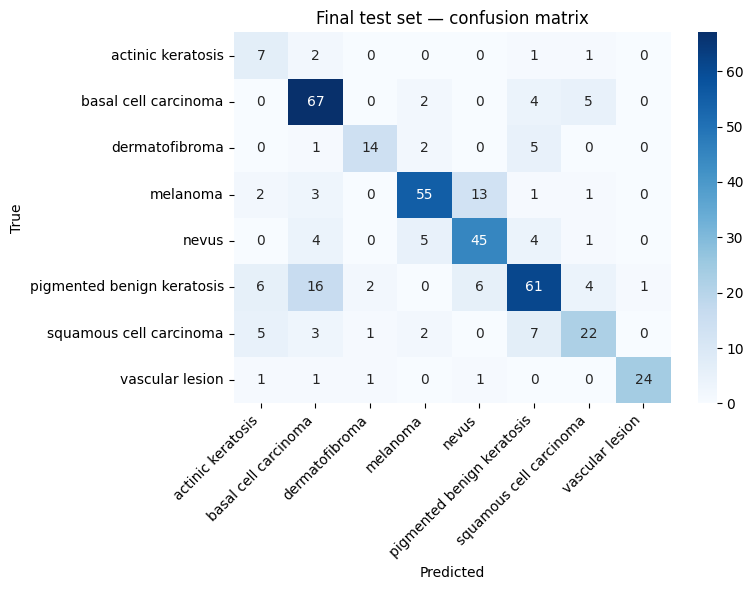

In [ ]:
y_true_test, y_pred_test = collect_predictions(transfer_model, transfer_test_loader, DEVICE)

cm = confusion_matrix(y_true_test, y_pred_test)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Final test set — confusion matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / 'test_confusion.png', dpi=100, bbox_inches='tight')
plt.show()



In [ ]:
print(classification_report(y_true_test, y_pred_test, target_names=class_names, digits=3, zero_division=0))

                            precision    recall  f1-score   support

         actinic keratosis      0.333     0.636     0.438        11
      basal cell carcinoma      0.691     0.859     0.766        78
            dermatofibroma      0.778     0.636     0.700        22
                  melanoma      0.833     0.733     0.780        75
                     nevus      0.692     0.763     0.726        59
pigmented benign keratosis      0.735     0.635     0.682        96
   squamous cell carcinoma      0.647     0.550     0.595        40
           vascular lesion      0.960     0.857     0.906        28

                  accuracy                          0.721       409
                 macro avg      0.709     0.709     0.699       409
              weighted avg      0.737     0.721     0.723       409



## Conclusion

Transfer learning won. The frozen ConvNeXt-Tiny reached 72.13% test accuracy, well past both models trained from scratch. On a small, imbalanced dataset, pretrained features beat a custom network.